In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv("/content/spam.csv", encoding="latin1")
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
len(data)

5572

In [ ]:
data['v1'].value_counts(normalize=True)

,proportion
v1,
ham,0.865937
spam,0.134063


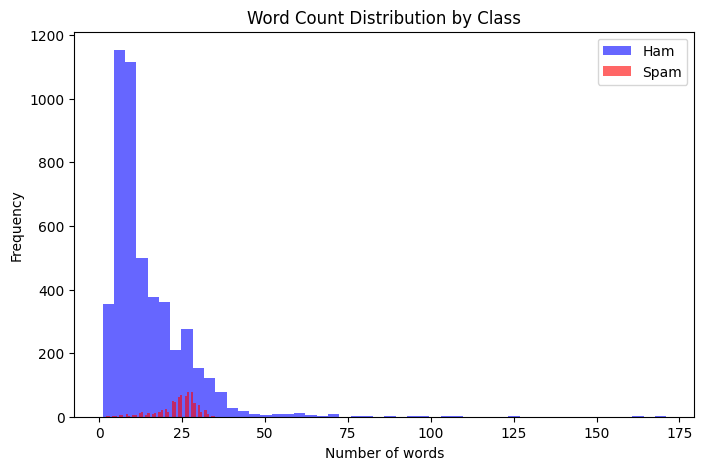

In [ ]:
import matplotlib.pyplot as plt
ham_lengths = [len(x.split()) for x in data[data['v1'] == 'ham']['v2']]
spam_lengths = [len(x.split()) for x in data[data['v1'] == 'spam']['v2']]

plt.figure(figsize=(8,5))

plt.hist(ham_lengths, bins=50, alpha=0.6, label='Ham', color='blue')
plt.hist(spam_lengths, bins=50, alpha=0.6, label='Spam', color='red')

plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.title("Word Count Distribution by Class")
plt.legend()

plt.show()

In [ ]:
data.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1,inplace=True)
print(data.head())

     v1                                                 v2
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [ ]:
import spacy
import re
from tqdm import tqdm

nlp = spacy.load("en_core_web_sm")

def preprocess_texts(texts):
    processed_texts = []
    for doc in tqdm(nlp.pipe(texts, batch_size=50), total=len(data)):
        tokens = [
            token.lemma_
            for token in doc
            if token.is_alpha and
            not token.is_stop and
            token.pos_ in {"NOUN", "VERB", "ADJ","PRON"}
        ]
        processed_texts.append(tokens)
    return processed_texts

processed_texts = preprocess_texts(data['v2'])
for i, t in enumerate(processed_texts[:5], 1):
    print(f"Text {i}: {t}\n")

100%|██████████| 5572/5572 [00:19<00:00, 291.02it/s]

Text 1: ['crazy', 'available', 'great', 'world', 'get', 'wat']

Text 2: ['lar', 'joke', 'wif', 'u', 'oni']

Text 3: ['free', 'entry', 'wkly', 'comp', 'win', 'final', 'tkts', 'text', 'fa', 'receive', 'entry', 'txt', 'apply']

Text 4: ['u', 'dun', 'early', 'hor', 'u']

Text 5: ['think', 'go', 'usf', 'live']



In [ ]:
import pickle

with open("processed_texts.pkl", "wb") as f:
    pickle.dump(processed_texts, f)

In [ ]:
from collections import Counter
word_freq = Counter()

for tokens in processed_texts:
    word_freq.update(tokens)

print(word_freq.most_common(20))

[('u', 898), ('go', 329), ('come', 318), ('know', 281), ('send', 274), ('get', 258), ('good', 257), ('free', 246), ('want', 242), ('day', 228), ('time', 225), ('tell', 209), ('love', 206), ('text', 202), ('think', 195), ('need', 185), ('today', 164), ('stop', 150), ('txt', 148), ('week', 137)]


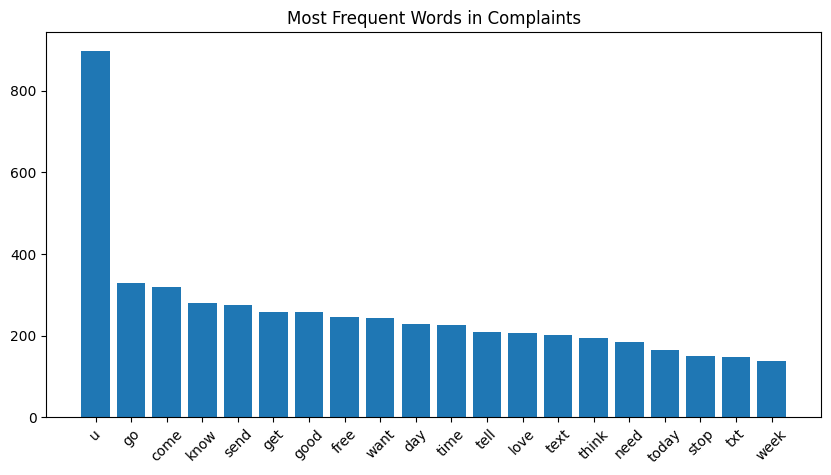

In [ ]:
import matplotlib.pyplot as plt
common_words = word_freq.most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)

plt.xticks(rotation=45)
plt.title("Most Frequent Words in Complaints")

plt.show()

In [ ]:
labels = data['v1']

In [ ]:
from sklearn.model_selection import train_test_split
clean_docs = [" ".join(doc) for doc in processed_texts]
X_train, X_test, y_train, y_test = train_test_split(
    clean_docs, labels, test_size=0.2, random_state=42, stratify=labels
)

In [ ]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    min_df=2, # => Min Number appare in document DF
    max_df=0.80 # in document
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train_tfidf, y_train)

print("TF-IDF matrix shape:", X_train_tfidf.shape)

TF-IDF matrix shape: (4457, 1846)


In [ ]:
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_bal)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train_bal)
weight_dict = dict(zip(classes, class_weights))

model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=None,
    subsample=0.8,
    scale_pos_weight=1,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

sample_weights = y_train_bal.map(weight_dict)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train_bal)
y_test_encoded = le.transform(y_test)

model.fit(X_train_bal, y_train_encoded, sample_weight=sample_weights)

y_pred = model.predict(X_test_tfidf)

acc = accuracy_score(y_test_encoded, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9632286995515695


In [ ]:
import pandas as pd
pd.Series(y_test_encoded).value_counts()

,count
0,966
1,149


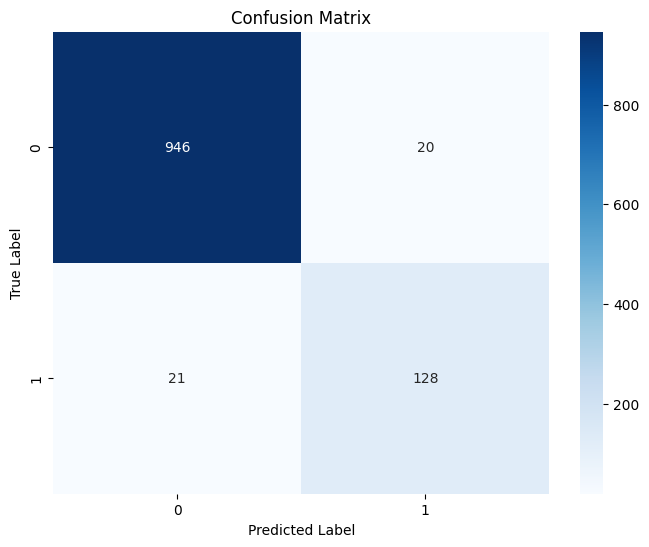

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test_encoded, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       966
           1       0.86      0.86      0.86       149

    accuracy                           0.96      1115
   macro avg       0.92      0.92      0.92      1115
weighted avg       0.96      0.96      0.96      1115



In [ ]:
with open("xgboost_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [ ]:
import joblib
joblib.dump(model, "xgboost_model.joblib")
joblib.dump(vectorizer, "tfidf_vectorizer.joblib")
joblib.dump(preprocess_texts, "processed_texts.joblib")

['processed_texts.joblib']

In [ ]:
from sklearn.naive_bayes import MultinomialNB

In [ ]:
model = MultinomialNB(alpha=1.0)

model.fit(X_train_tfidf, y_train_encoded)

MultinomialNB()

In [ ]:
y_pred = model.predict(X_test_tfidf)

In [ ]:
print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       966
           1       0.96      0.75      0.84       149

    accuracy                           0.96      1115
   macro avg       0.96      0.87      0.91      1115
weighted avg       0.96      0.96      0.96      1115



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
num_classes = len(set(y_train_encoded))
y_train_cat = tf.keras.utils.to_categorical(y_train_encoded, num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test_encoded, num_classes)

In [ ]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='sigmoid')
])

# Compile model
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       945,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,077,506 (4.11 MB)

 Trainable params: 1,077,506 (4.11 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_tfidf, y_train_cat,
    validation_split=0.1,
    epochs=10,
    batch_size=64
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.8684 - loss: 0.3286 - val_accuracy: 0.8677 - val_loss: 0.2332
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.9541 - loss: 0.1303 - val_accuracy: 0.9619 - val_loss: 0.1283
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9808 - loss: 0.0562 - val_accuracy: 0.9686 - val_loss: 0.1056
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9905 - loss: 0.0292 - val_accuracy: 0.9731 - val_loss: 0.1009
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9965 - loss: 0.0145 - val_accuracy: 0.9776 - val_loss: 0.1005
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.9975 - loss: 0.0095 - val_accuracy: 0.9776 - val_loss: 0.1125
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9980 - loss: 0.0095 - val_accuracy: 0.9753 - val_loss: 0.1060
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9988 - loss: 0.0066 - val_accuracy: 0.9753 - 

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


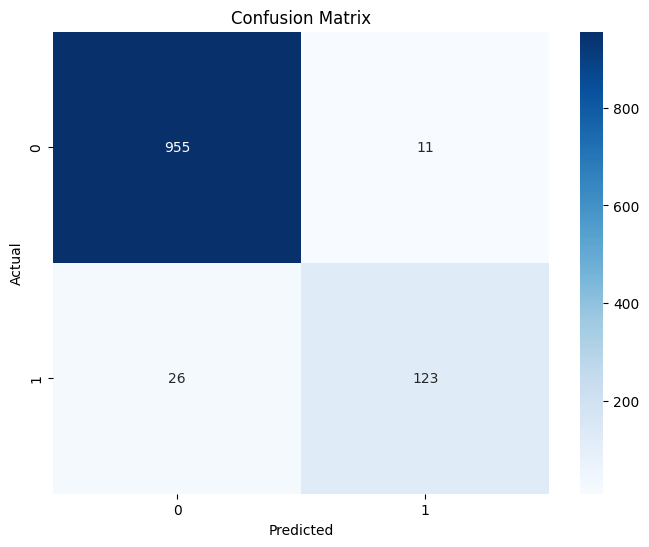

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       966
           1       0.92      0.83      0.87       149

    accuracy                           0.97      1115
   macro avg       0.95      0.91      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [ ]:
y_pred_prob = model.predict(X_test_tfidf)
y_pred = y_pred_prob.argmax(axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_test_encoded, y_pred))